## **양자화**

양자화(Quantization)란 **연속적인(Analog) 값을 일정한 간격을 가진 이산적인(Digital) 값**으로 바꾸는 과정을 말합니다.

AI 모델은 보통 소수점이 길게 붙는 정밀한 숫자(Float32, 32비트 부동소수점)로 계산을 합니다. 양자화 적용하면 이 복잡한 소수점 데이터들을 가볍고 단순한 정수(Int8, 8비트 정수) 형태로 변환합니다. 모델의 용량이 1/4 수준으로 줄어듭니다.(약간의 정확도 손실은 발생할 수 있습니다.)

파인튜닝에서의 양자화는 **거대 모델을 4비트로 꽁꽁 얼려(Freeze) 메모리를 아끼고, 옆에 가벼운 어댑터(LoRA)만 붙여서 저비용·고효율로 AI를 맞춤 학습시키는 기술**입니다.

### **숫자 8개로 양자화 원리 한눈에 보기**

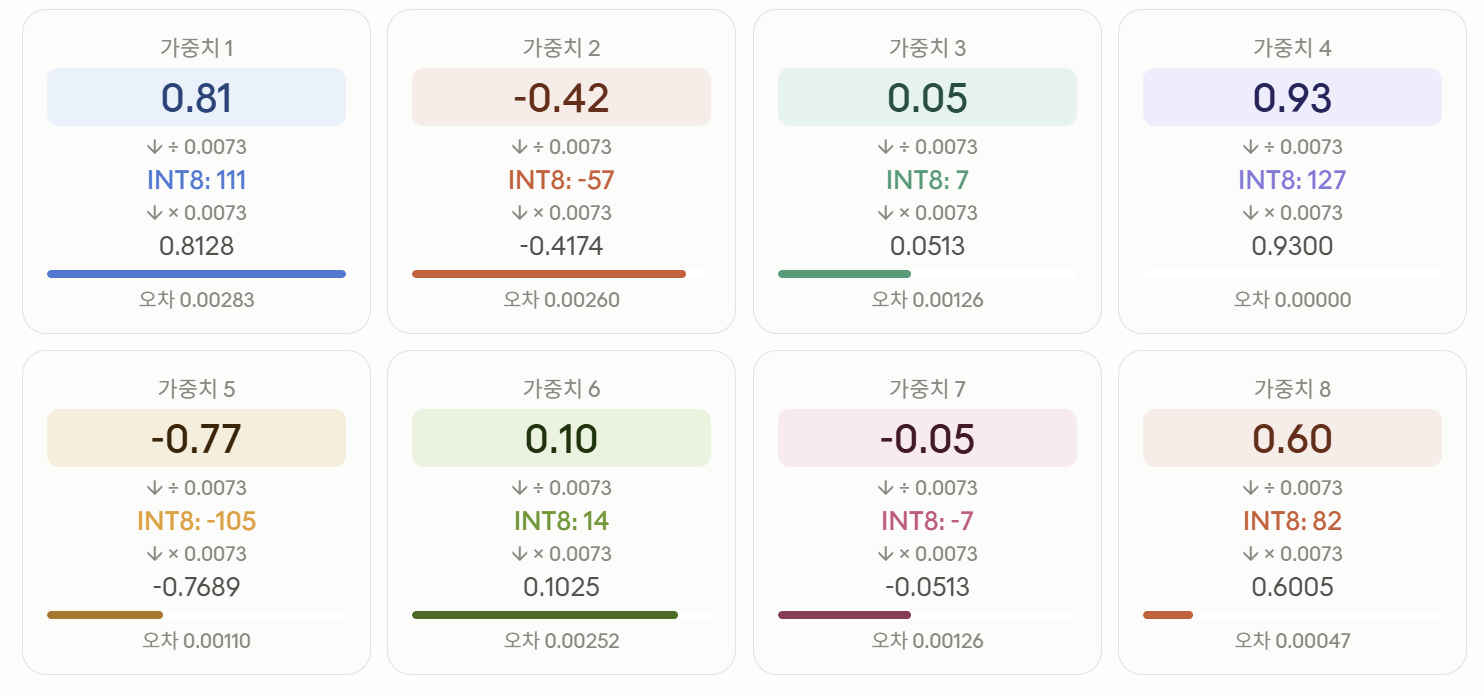

In [1]:
# 신경망의 가중치 8개라고 가정한 작은 숫자 목록
original_numbers = [0.81, -0.42, 0.05, 0.93, -0.77, 0.10, -0.05, 0.60]

print("원본 숫자(FP32라고 가정) :", original_numbers)

원본 숫자(FP32라고 가정) : [0.81, -0.42, 0.05, 0.93, -0.77, 0.1, -0.05, 0.6]


In [2]:
# -----------------------------------------------------------------
# 1단계: scale 값 구하기
# -----------------------------------------------------------------
# INT8은 -127 ~ 127 사이의 정수만 표현할 수 있습니다.
# 원본 숫자 중 절댓값이 가장 큰 값을 127에 대응시키면,
# 나머지 숫자들도 자연스럽게 -127~127 범위 안으로 들어오게 됩니다.
max_value = max(abs(n) for n in original_numbers)
scale = max_value / 127

print(f"\n절댓값이 가장 큰 값: {max_value}")
print(f"scale 값 = {max_value} / 127 = {scale:.6f}")


절댓값이 가장 큰 값: 0.93
scale 값 = 0.93 / 127 = 0.007323


In [3]:
# -----------------------------------------------------------------
# 2단계: 정수로 변환 (양자화)
# -----------------------------------------------------------------
quantized_numbers = []
for n in original_numbers:
    q = round(n / scale)  # scale로 나눈 뒤 정수로 반올림
    quantized_numbers.append(q)


In [4]:
# -----------------------------------------------------------------
# 3단계: 다시 실수로 복원 (역양자화)
# -----------------------------------------------------------------
dequantized_numbers = [q * scale for q in quantized_numbers]

In [5]:
# -----------------------------------------------------------------
# 결과를 표 형태로 출력
# -----------------------------------------------------------------
print("\n{:<10} {:<12} {:<10} {:<14} {:<10}".format(
    "원본", "÷scale", "INT8 값", "복원값(×scale)", "오차"
))
print("-" * 60)
for original, q, dequant in zip(original_numbers, quantized_numbers, dequantized_numbers):
    error = abs(original - dequant)
    print("{:<10} {:<12} {:<10} {:<14.6f} {:<10.6f}".format(
        original, round(original / scale, 3), q, dequant, error
    ))


원본         ÷scale       INT8 값     복원값(×scale)    오차        
------------------------------------------------------------
0.81       110.613      111        0.812835       0.002835  
-0.42      -57.355      -57        -0.417402      0.002598  
0.05       6.828        7          0.051260       0.001260  
0.93       127.0        127        0.930000       0.000000  
-0.77      -105.151     -105       -0.768898      0.001102  
0.1        13.656       14         0.102520       0.002520  
-0.05      -6.828       -7         -0.051260      0.001260  
0.6        81.935       82         0.600472       0.000472  


In [6]:
avg_error = sum(abs(o - d) for o, d in zip(original_numbers, dequantized_numbers)) / len(original_numbers)
print("-" * 60)
print(f"평균 오차: {avg_error:.6f}  (원본 값들이 보통 0~1 사이인 것에 비하면 매우 작은 오차)")

print("\n[정리]")
print("- INT8 값 칸을 보면 전부 -127~127 사이의 '정수'만 있는 걸 확인할 수 있습니다.")
print("- 이 정수들만 저장하면 원래 실수보다 훨씬 적은 메모리를 사용합니다.")
print("- 복원값은 원본과 100% 같지는 않지만(오차 있음), 거의 비슷한 값으로 돌아옵니다.")
print("- scale 값 하나만 따로 기억해두면, 언제든 정수 -> 실수로 복원할 수 있습니다.")

------------------------------------------------------------
평균 오차: 0.001506  (원본 값들이 보통 0~1 사이인 것에 비하면 매우 작은 오차)

[정리]
- INT8 값 칸을 보면 전부 -127~127 사이의 '정수'만 있는 걸 확인할 수 있습니다.
- 이 정수들만 저장하면 원래 실수보다 훨씬 적은 메모리를 사용합니다.
- 복원값은 원본과 100% 같지는 않지만(오차 있음), 거의 비슷한 값으로 돌아옵니다.
- scale 값 하나만 따로 기억해두면, 언제든 정수 -> 실수로 복원할 수 있습니다.


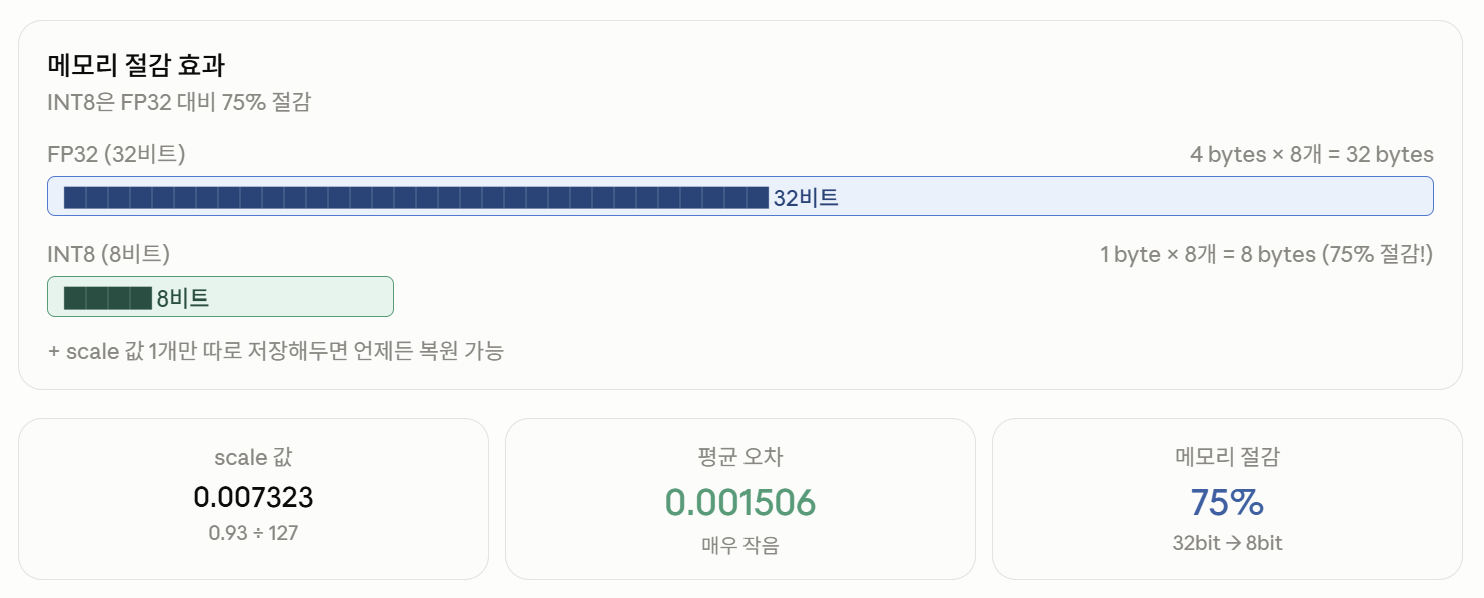

### **이미지 색상 단계 줄이기 = 양자화를 눈으로 보기**

- 양자화(Quantization)라는 단어는 원래 이미지/오디오 처리에서도 쓰입니다.
- 사진의 색상을 256단계(8bit) -> 16단계(4bit) -> 4단계(2bit)로 줄여보면,
  **정밀도를 낮춰서 용량을 줄이지만 전체적인 형태는 유지된다**는 양자화의 느낌을 눈으로 확인할 수 있습니다.

- 실행하면 결과 이미지 4장(원본, 8bit, 4bit, 2bit)이 output/ 폴더에 저장됩니다.

In [7]:
import os
import numpy as np
from PIL import Image, ImageDraw

In [8]:
def make_sample_image(size=(300, 200)):
    """그라데이션 + 원이 있는 간단한 샘플 이미지를 직접 그려서 만듭니다."""
    width, height = size
    # 가로로 0~255까지 부드럽게 변하는 흑백 그라데이션 만들기
    gradient = np.tile(np.linspace(0, 255, width), (height, 1)).astype(np.uint8)
    img = Image.fromarray(gradient, mode="L").convert("RGB")

    draw = ImageDraw.Draw(img)
    draw.ellipse((60, 40, 240, 160), fill=(255, 120, 40))  # 그라데이션 위에 원 하나
    return img

In [9]:
def quantize_image(img: Image.Image, bits: int) -> Image.Image:
    """
    이미지의 색상 정밀도를 낮추는 함수.
    bits=8 이면 원본 그대로(256단계), bits가 낮아질수록 표현 가능한 색 단계가 줄어듭니다.
    원리는 숫자 양자화와 완전히 동일합니다: scale을 구해서 -> 정수로 변환 -> 다시 복원.
    """
    levels = 2 ** bits  # 표현 가능한 색상 단계 수 (예: 4bit -> 16단계)
    arr = np.array(img).astype(np.float32)

    scale = 255 / (levels - 1)
    quantized = np.round(arr / scale)          # 정수 단계로 변환 (양자화)
    restored = (quantized * scale).clip(0, 255).astype(np.uint8)  # 다시 0~255로 복원

    return Image.fromarray(restored), levels

In [10]:
out_dir = os.path.join("output")
os.makedirs(out_dir, exist_ok=True)
original = make_sample_image()
original.save(os.path.join(out_dir, "original_8bit_256levels.png"))
print("원본 이미지 저장 완료: 색상 256단계 (8bit, 일반적인 이미지와 동일)")

for bits in [4, 2, 1]:
    quantized_img, levels = quantize_image(original, bits)
    filename = f"quantized_{bits}bit_{levels}levels.png"
    quantized_img.save(os.path.join(out_dir, filename))
    print(f"{bits}bit 양자화 완료: 색상 {levels}단계만 사용 -> {filename}")

# 4장을 한 번에 비교할 수 있도록 위아래로 이어붙인 합성 이미지도 만들어 둡니다.
from PIL import ImageDraw as _ImageDraw
paths = [
        ("original_8bit_256levels.png", "Original (8bit, 256 levels)"),
        ("quantized_4bit_16levels.png", "4bit (16 levels)"),
        ("quantized_2bit_4levels.png", "2bit (4 levels)"),
        ("quantized_1bit_2levels.png", "1bit (2 levels)"),
]
imgs = [Image.open(os.path.join(out_dir, p)) for p, _ in paths]
w, h = imgs[0].size
combo = Image.new("RGB", (w, (h + 10) * len(imgs)), "white")
draw = _ImageDraw.Draw(combo)
y = 0
for im, (_, label) in zip(imgs, paths):
    combo.paste(im, (0, y))
    draw.text((5, y + 5), label, fill="yellow")
    y += h + 10
combo.save(os.path.join(out_dir, "comparison_all.png"))
print("\n4장을 한눈에 비교할 수 있는 'comparison_all.png'도 함께 저장합니다.")

print(f"\n결과 이미지들이 '{out_dir}' 폴더에 저장되었습니다.")
print("4장을 나란히 열어서 비교해보면:")
print("- 8bit(256단계): 원본과 동일, 부드러운 그라데이션")
print("- 4bit(16단계) : 약간의 색상 띠(banding)가 보이지만 전체 형태는 그대로")
print("- 2bit(4단계)  : 색상 띠가 뚜렷하게 보이지만 원이 어디 있는지는 여전히 알아볼 수 있음")
print("- 1bit(2단계)  : 흑/백 둘로만 나뉘어 정보 손실이 크지만, 형태의 윤곽은 남아있음")
print("\n[핵심] 비트 수를 줄일수록 '용량은 줄지만 손실은 커지는' 트레이드오프가")
print("       신경망 가중치 양자화에서도 똑같이 발생합니다.")

원본 이미지 저장 완료: 색상 256단계 (8bit, 일반적인 이미지와 동일)
4bit 양자화 완료: 색상 16단계만 사용 -> quantized_4bit_16levels.png
2bit 양자화 완료: 색상 4단계만 사용 -> quantized_2bit_4levels.png
1bit 양자화 완료: 색상 2단계만 사용 -> quantized_1bit_2levels.png

4장을 한눈에 비교할 수 있는 'comparison_all.png'도 함께 저장합니다.

결과 이미지들이 'output' 폴더에 저장되었습니다.
4장을 나란히 열어서 비교해보면:
- 8bit(256단계): 원본과 동일, 부드러운 그라데이션
- 4bit(16단계) : 약간의 색상 띠(banding)가 보이지만 전체 형태는 그대로
- 2bit(4단계)  : 색상 띠가 뚜렷하게 보이지만 원이 어디 있는지는 여전히 알아볼 수 있음
- 1bit(2단계)  : 흑/백 둘로만 나뉘어 정보 손실이 크지만, 형태의 윤곽은 남아있음

[핵심] 비트 수를 줄일수록 '용량은 줄지만 손실은 커지는' 트레이드오프가
       신경망 가중치 양자화에서도 똑같이 발생합니다.


### **비트 수가 줄어들수록 오차는 얼마나 커질까?**

- 8bit, 6bit, 4bit, 3bit, 2bit로 같은 데이터를 양자화했을 때
오차(평균 제곱 오차, MSE)가 어떻게 변하는지 그래프로 확인합니다.

- **비트를 줄이면 용량은 작아지지만 오차는 커진다**는 트레이드오프를
숫자와 그래프로 직접 눈으로 보는 예제입니다.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def quantize(data: np.ndarray, bits: int) -> tuple[np.ndarray, float]:
    """
    데이터를 주어진 bit 수로 양자화합니다.
    bits=8 이면 -127~127, bits=4 이면 -7~7 처럼 표현 가능한 정수 범위가 줄어듭니다.
    """
    max_int = 2 ** (bits - 1) - 1  # 예: 8bit -> 127, 4bit -> 7, 2bit -> 1
    max_val = np.abs(data).max()
    scale = max_val / max_int

    quantized = np.clip(np.round(data / scale), -max_int, max_int)
    restored = quantized * scale
    return restored, scale

In [13]:
out_dir = os.path.join("output")
os.makedirs(out_dir, exist_ok=True)

# 신경망 가중치라고 가정한 데이터 (정규분포에서 샘플링)
rng = np.random.default_rng(seed=0)
data = rng.normal(loc=0.0, scale=1.0, size=20000).astype(np.float32)

bit_widths = [8, 6, 4, 3, 2]
mse_list = []
memory_list_mb = []

print(f"{'비트수':<8}{'표현가능 정수범위':<20}{'MSE(오차)':<16}{'메모리(상대비율)':<16}")
print("-" * 60)

for bits in bit_widths:
    restored, scale = quantize(data, bits)
    mse = float(np.mean((data - restored) ** 2))
    mse_list.append(mse)

    # FP32(32bit) 기준 메모리 사용 비율
    relative_memory = bits / 32
    memory_list_mb.append(relative_memory * 100)
    max_int = 2 ** (bits - 1) - 1
    print(f"{bits:<8}{f'-{max_int}~{max_int}':<20}{mse:<16.8f}{relative_memory * 100:<16.1f}")

비트수     표현가능 정수범위           MSE(오차)         메모리(상대비율)       
------------------------------------------------------------
8       -127~127            0.00008372      25.0            
6       -31~31              0.00138345      18.8            
4       -7~7                0.02758024      12.5            
3       -3~3                0.15140608      9.4             
2       -1~1                0.85989529      6.2             



그래프 저장 완료: output\bit_width_vs_error.png


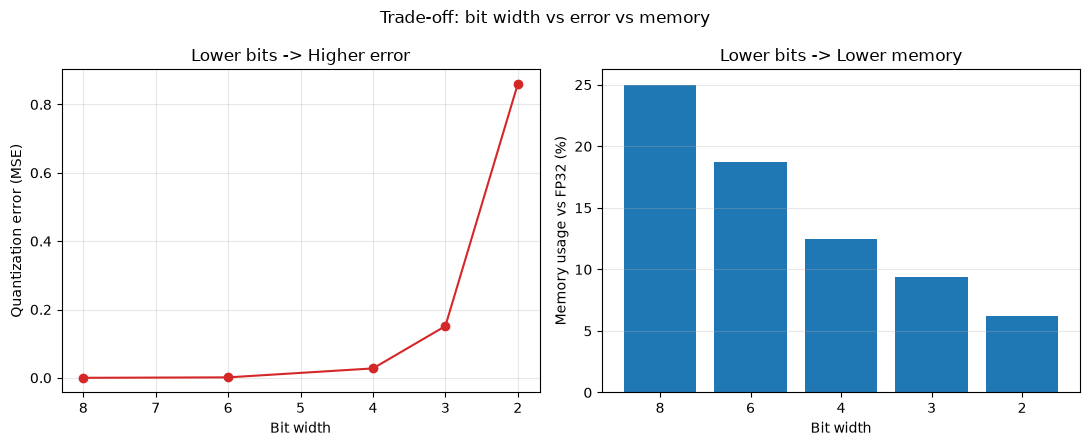

In [14]:
# ---- 그래프 그리기 ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(bit_widths, mse_list, marker="o", color="tab:red")
ax1.set_xlabel("Bit width")
ax1.set_ylabel("Quantization error (MSE)")
ax1.set_title("Lower bits -> Higher error")
ax1.invert_xaxis()  # 왼쪽일수록 비트 수가 적게 보이도록
ax1.grid(True, alpha=0.3)

ax2.bar([str(b) for b in bit_widths], memory_list_mb, color="tab:blue")
ax2.set_xlabel("Bit width")
ax2.set_ylabel("Memory usage vs FP32 (%)")
ax2.set_title("Lower bits -> Lower memory")
ax2.grid(True, alpha=0.3, axis="y")

fig.suptitle("Trade-off: bit width vs error vs memory", fontsize=12)
fig.tight_layout()

save_path = os.path.join(out_dir, "bit_width_vs_error.png")
fig.savefig(save_path, dpi=130)
print(f"\n그래프 저장 완료: {save_path}")

**[정리]**
- 비트 수가 8 -> 2로 줄어들수록 오차(MSE)는 빠르게 커집니다.
- 동시에 메모리 사용량은 비트 수에 정확히 비례해서 줄어듭니다.
- 실제 LLM 양자화에서는 4bit 근처를 '꽤 괜찮은 절충점'으로 많이 사용합니다.
  (GPTQ, AWQ 같은 정교한 기법들은 이 4bit 구간의 오차를 더 줄이기 위한 방법들입니다)

### **양자화의 수학적 원리 이해하기**
실제로 연속적인 소수점 데이터가 어떻게 정수로 압축(양자화)되고 다시 복원(역양자화)되는지 눈으로 확인하는 코드입니다

In [15]:
import numpy as np

# 1. 원래 데이터 (FP32 화질의 정밀한 소수점 데이터)
original_data = np.array([-1.5, -0.2, 0.0, 0.8, 2.5], dtype=np.float32)

# 2. 양자화 (Symmetric INT8 Quantization)
# 절댓값이 가장 큰 값을 기준으로 Scale 계산
abs_max = np.max(np.abs(original_data))
scale = abs_max / 127

# FP32 → INT8
quantized_data = np.round(original_data / scale).astype(np.int8)

# 3. 역양자화 (INT8 → FP32)
dequantized_data = quantized_data.astype(np.float32) * scale

print("--- INT8 양자화 기본 원리 ---")
print(f"원래 데이터          : {original_data}")
print(f"절댓값 최대(abs_max) : {abs_max:.4f}")
print(f"Scale               : {scale:.6f}")
print(f"양자화(INT8)         : {quantized_data}")
print(f"복원(FP32)           : {dequantized_data}")
print(f"오차                 : {original_data - dequantized_data}")

--- INT8 양자화 기본 원리 ---
원래 데이터          : [-1.5 -0.2  0.   0.8  2.5]
절댓값 최대(abs_max) : 2.5000
Scale               : 0.019685
양자화(INT8)         : [-76 -10   0  41 127]
복원(FP32)           : [-1.496063   -0.19685039  0.          0.8070866   2.5       ]
오차                 : [-0.00393701 -0.00314961  0.         -0.00708658  0.        ]


### **PyTorch를 이용한 가중치(Weights) 용량 비교**
딥러닝 모델의 무게(용량)가 얼마나 줄어드는지 인공신경망의 한 레이어를 만들어 비교합니다.

In [16]:
import warnings

warnings.filterwarnings("ignore")

In [17]:
import os
import copy
import torch
from torchao.quantization import quantize_, Int8WeightOnlyConfig
 
 
# ── 1. 가상의 큰 신경망 레이어 생성 (FP32 표준)
model_fp32 = torch.nn.Linear(1000, 1000)
print("원본 모델 dtype :", model_fp32.weight.dtype)   # torch.float32
 
 
# ── 2. torchao 최신 API로 INT8 양자화
#    - quantize_() 는 모델을 in-place 로 수정합니다 (새 변수 불필요)
#    - Int8WeightOnlyConfig : 가중치만 INT8로 변환 (가장 안전하고 범용적)
model_int8 = copy.deepcopy(model_fp32)                    # 원본 보존을 위해 복사
quantize_(model_int8, Int8WeightOnlyConfig(version=2))    # version=2: 0.17.0+ 경고 제거
 
 
# ── 3. 각각 저장해서 파일 크기 비교
torch.save(model_fp32.state_dict(), "model_fp32.pth")
torch.save(model_int8.state_dict(), "model_int8.pth")
 
size_fp32 = os.path.getsize("model_fp32.pth") / (1024 * 1024)
size_int8 = os.path.getsize("model_int8.pth") / (1024 * 1024)
 
print("\n--- 모델 용량 비교 ---")
print(f"양자화 전 모델 크기 (FP32): {size_fp32:.2f} MB")
print(f"양자화 후 모델 크기 (INT8): {size_int8:.2f} MB  <- 약 1/4로 압축 완료!")
print(f"압축률 : {(1 - size_int8 / size_fp32) * 100:.1f}% 절감")
 
 
# ── 4. 가중치 타입 확인 (양자화 전/후 비교)
print("\n--- 가중치 타입 확인 ---")
print("FP32 weight type :", type(model_fp32.weight).__name__)
print("INT8 weight type :", type(model_int8.weight).__name__)
 

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
W0704 13:43:02.939000 7252 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


원본 모델 dtype : torch.float32

--- 모델 용량 비교 ---
양자화 전 모델 크기 (FP32): 3.82 MB
양자화 후 모델 크기 (INT8): 0.96 MB  <- 약 1/4로 압축 완료!
압축률 : 74.7% 절감

--- 가중치 타입 확인 ---
FP32 weight type : Parameter
INT8 weight type : Int8Tensor


In [18]:
# ── 정리 (임시 파일 삭제)
os.remove("model_fp32.pth")
os.remove("model_int8.pth")

가중치 하나가 4바이트(FP32)에서 1바이트(INT8)로 줄었기 때문에, 파일 크기도 정확히 4분의 1이 됩니다. 이것이 양자화가 메모리를 절감하는 원리입니다.

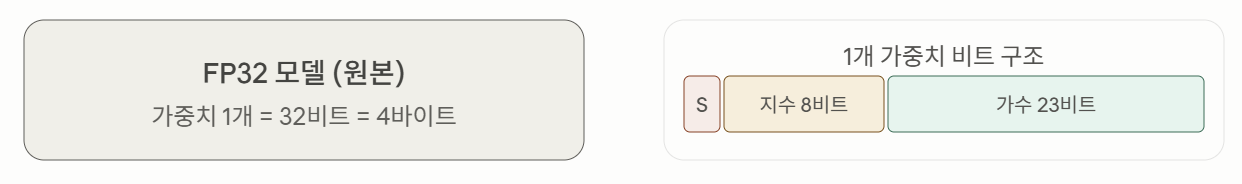

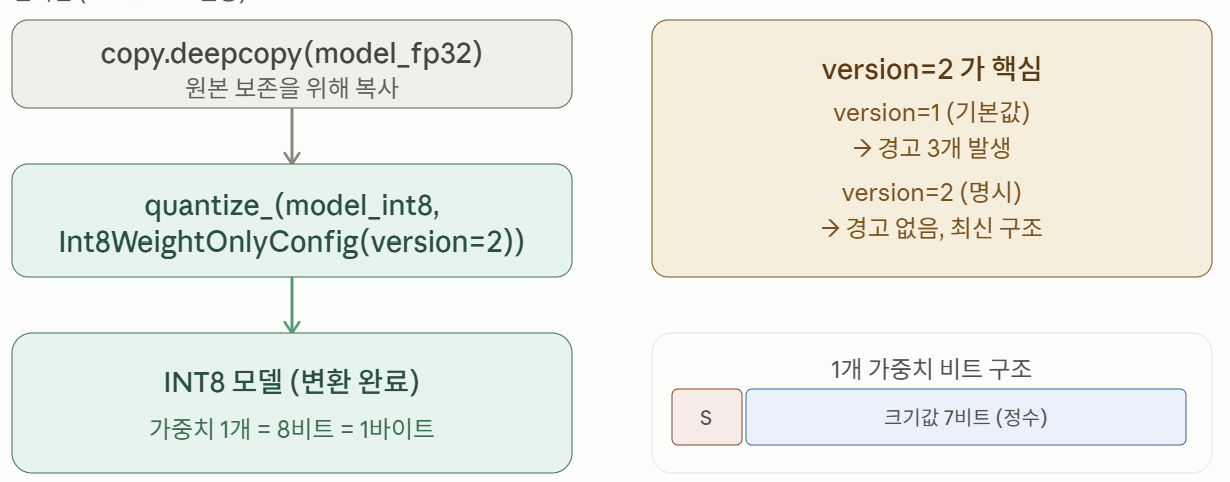

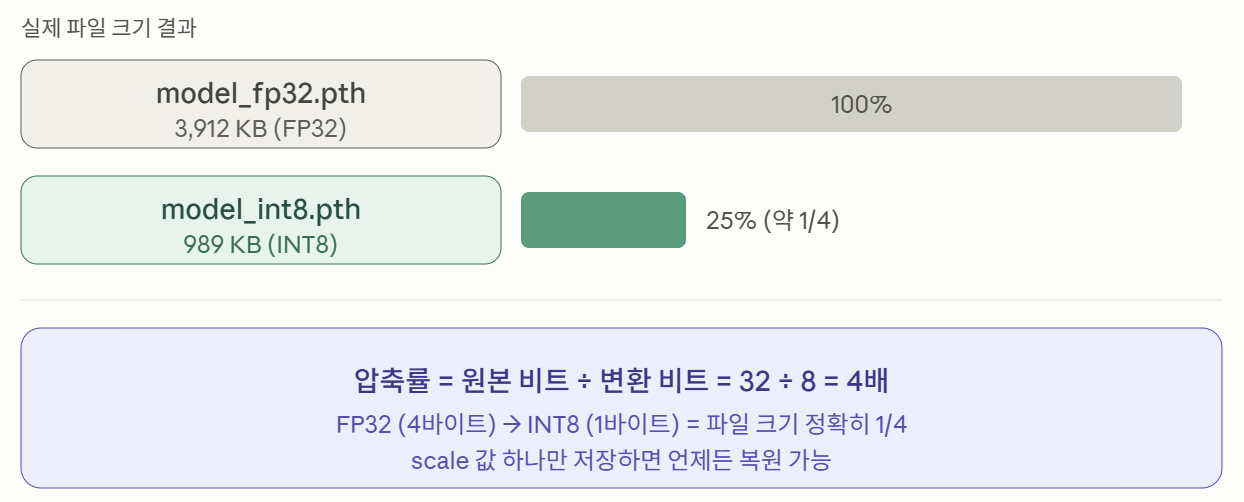

### **Hugging Face transformers로 LLM 8비트/4비트 로드하기**

파인튜닝할 때 가장 많이 쓰이는 방식입니다. **bitsandbytes** 라이브러리를 활용해 모델을 불러올 때부터 용량을 줄여서 내 컴퓨터 메모리(VRAM)를 아끼는 방법입니다.

In [24]:
from transformers.utils import logging

# log난 warning 출력 방지
logging.set_verbosity_error()

In [20]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import BitsAndBytesConfig
import torch

model_id = "facebook/opt-125m"   # 테스트용 가벼운 모델

# 1. 일반적인 방식으로 모델 로드 (FP16)
#    dtype= 은 Deprecated → torch_dtype= 으로 변경
model_normal = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,   # ← dtype= 에서 torch_dtype= 으로 수정
)

# 2. 4비트(4-bit)로 극단적으로 양자화하여 로드
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",             # NF4 데이터타입 (QLoRA 표준), 정규분포 기반의 양자화
    bnb_4bit_compute_dtype=torch.bfloat16, # 연산은 BF16
    bnb_4bit_use_double_quant=True,        # 이중 양자화로 추가 절감
)
model_4bit = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
)

print("--- LLM 로드 방식 비교 ---")
print(f"일반 모델 데이터 타입    : {model_normal.dtype}")
print(f"4비트 양자화 타입        : {model_4bit.config.quantization_config.bnb_4bit_quant_type}")
print(f"4비트 연산 dtype         : {model_4bit.config.quantization_config.bnb_4bit_compute_dtype}")
print()
print(f"일반 모델 메모리         : {model_normal.get_memory_footprint() / 1024**2:,.1f} MB")
print(f"4비트 모델 메모리        : {model_4bit.get_memory_footprint() / 1024**2:,.1f} MB")
print()
print("=> 4비트 양자화를 쓰면 VRAM 사용량이 눈에 띄게 줄어들어 개인 PC에서도 LLM을 돌릴 수 있습니다.")

config.json:   0%|          | 0.00/651 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/251M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/251M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

--- LLM 로드 방식 비교 ---
일반 모델 데이터 타입    : torch.float16
4비트 양자화 타입        : nf4
4비트 연산 dtype         : torch.bfloat16

일반 모델 메모리         : 238.9 MB
4비트 모델 메모리        : 117.4 MB

=> 4비트 양자화를 쓰면 VRAM 사용량이 눈에 띄게 줄어들어 개인 PC에서도 LLM을 돌릴 수 있습니다.


### **양자화 전후의 추론 속도(Speed) 비교**

양자화를 하면 컴퓨터가 계산하기 편해져서 답변을 내어주는 속도가 얼마나 빨라지는지 측정합니다.

In [28]:
import torch
import copy
import time
from torchao.quantization import quantize_, Int8WeightOnlyConfig


# 1. 모델 및 가상 입력 데이터 준비
model_fp32 = torch.nn.Linear(2048, 2048)

#    torch.ao.quantization.quantize_dynamic() → torchao quantize_() 로 교체
#    Int8WeightOnlyConfig(version=2) : CPU 환경에서도 속도 향상 확인 가능
#    Int8DynamicActivationInt8WeightConfig 는 GPU 전용 → CPU 에서 오히려 느림
model_int8 = copy.deepcopy(model_fp32)
quantize_(model_int8, Int8WeightOnlyConfig(version=2))

dummy_input = torch.randn(32, 2048)


# 2. 양자화 전(FP32) 속도 측정
start = time.time()
for _ in range(100):
    _ = model_fp32(dummy_input)
end_fp32 = time.time() - start


# 3. 양자화 후(INT8) 속도 측정
start = time.time()
for _ in range(100):
    _ = model_int8(dummy_input)
end_int8 = time.time() - start


print("--- 추론 속도 비교 ---")
print(f"양자화 전 (FP32) 총 수행 시간 : {end_fp32:.4f}초")
print(f"양자화 후 (INT8) 총 수행 시간 : {end_int8:.4f}초")
if end_int8 < end_fp32:
    print(f"=> 양자화 후 속도가 약 {end_fp32 / end_int8:.1f}배 빨라졌습니다!")
else:
    print(f"=> CPU 환경에서는 INT8 이점이 제한적입니다. GPU에서 실행 시 속도 향상이 큽니다.")

--- 추론 속도 비교 ---
양자화 전 (FP32) 총 수행 시간 : 0.0393초
양자화 후 (INT8) 총 수행 시간 : 0.0552초
=> CPU 환경에서는 INT8 이점이 제한적입니다. GPU에서 실행 시 속도 향상이 큽니다.


파일 크기는 줄었습니다. 이것이 바로 1차 목적입니다. 속도는 CPU에서는 오히려 조금 느려질 수 있고, GPU에서 torch.compile()과 함께 쓸 때 비로소 빨라집니다. RTX 5060으로 실행하면 다른 결과가 나옵니다.

In [29]:
"""
추론 속도 비교 — GPU 버전
=====================================
GPU(CUDA) 에서 FP32 vs INT8 속도를 비교합니다.

실행 조건:
  - NVIDIA GPU 필수 (RTX 5060 등)
  - pip install torch torchao

핵심 포인트:
  - 모델과 입력을 .cuda() 로 GPU에 올려야 함
  - INT8 속도 향상은 torch.compile() 과 함께 사용할 때 극대화됨
  - GPU 시간 측정은 torch.cuda.synchronize() 필수
"""

import torch
import copy
import time
from torchao.quantization import quantize_, Int8WeightOnlyConfig


# ── GPU 확인
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"실행 장치: {device}")
if device == "cpu":
    print("※ GPU가 감지되지 않았습니다. CPU로 실행합니다.")
print()


# ── 1. 모델 생성 후 GPU로 이동
model_fp32 = torch.nn.Linear(2048, 2048).to(device)   # ← .to(device) 로 GPU 이동


# ── 2. INT8 양자화 후 GPU로 이동
model_int8 = copy.deepcopy(model_fp32).cpu()           # 양자화는 CPU에서 수행
quantize_(model_int8, Int8WeightOnlyConfig(version=2))
model_int8 = model_int8.to(device)                     # 양자화 후 GPU로 이동

# torch.compile() : GPU에서 INT8 속도 향상을 극대화하는 핵심
# (첫 실행 시 컴파일 시간이 걸리므로 워밍업 필수)
if device == "cuda":
    model_fp32 = torch.compile(model_fp32)
    model_int8 = torch.compile(model_int8)


# ── 3. 입력 데이터도 GPU로 이동
dummy_input = torch.randn(32, 2048).to(device)         # ← 입력도 .to(device) 필수


# ── GPU 시간 측정 함수
def measure_time(model, x, n=100):
    # 워밍업 (컴파일 + GPU 초기화 시간 제외)
    for _ in range(10):
        _ = model(x)
    if device == "cuda":
        torch.cuda.synchronize()    # ← GPU 작업 완료 대기 (필수)

    start = time.time()
    for _ in range(n):
        _ = model(x)
    if device == "cuda":
        torch.cuda.synchronize()    # ← 측정 종료 시에도 필수
    return time.time() - start


# ── 4. 속도 측정
print("워밍업 중...")
t_fp32 = measure_time(model_fp32, dummy_input)
t_int8 = measure_time(model_int8, dummy_input)


# ── 5. 결과 출력
print("--- [예제 4] 추론 속도 비교 (GPU) ---")
print(f"실행 장치              : {device.upper()}")
print(f"양자화 전 (FP32) 시간  : {t_fp32:.4f}초")
print(f"양자화 후 (INT8) 시간  : {t_int8:.4f}초")
if t_int8 < t_fp32:
    print(f"=> INT8이 약 {t_fp32 / t_int8:.1f}배 빠릅니다!")
else:
    print(f"=> 이 모델 크기에서는 속도 차이가 작습니다. 더 큰 모델일수록 차이가 커집니다.")

실행 장치: cuda

워밍업 중...
--- [예제 4] 추론 속도 비교 (GPU) ---
실행 장치              : CUDA
양자화 전 (FP32) 시간  : 0.0140초
양자화 후 (INT8) 시간  : 0.0230초
=> 이 모델 크기에서는 속도 차이가 작습니다. 더 큰 모델일수록 차이가 커집니다.


#### 다음 경고 오류가 발생할 수 있으나 수행하는데는 문제 없습니다.
SM (Streaming Multiprocessor) 수가 부족해서 max_autotune_gemm 모드를 사용할 수 없습니다.

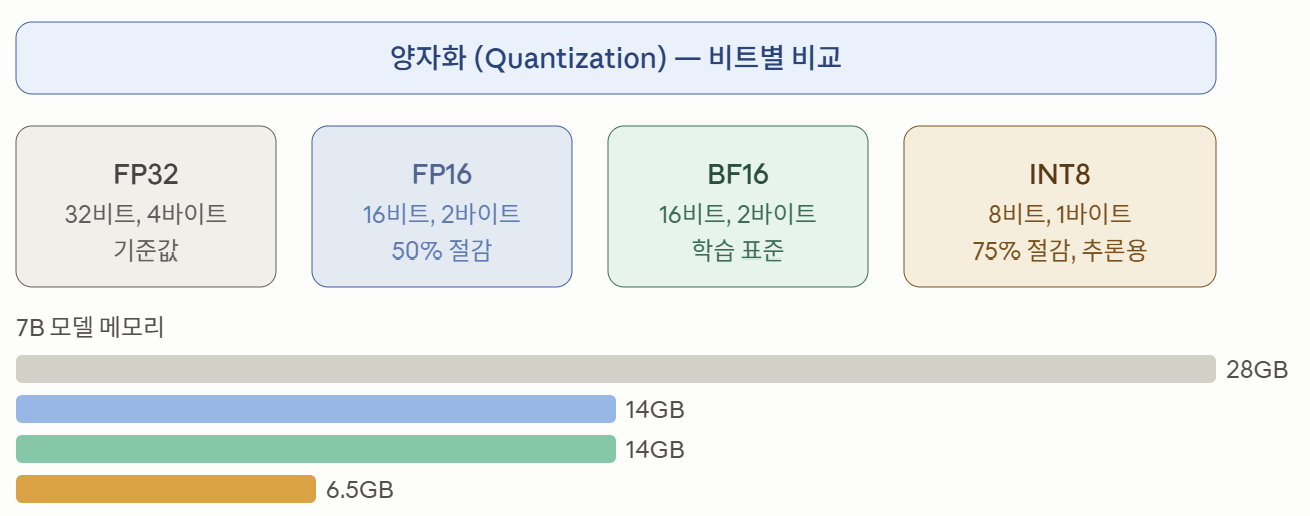

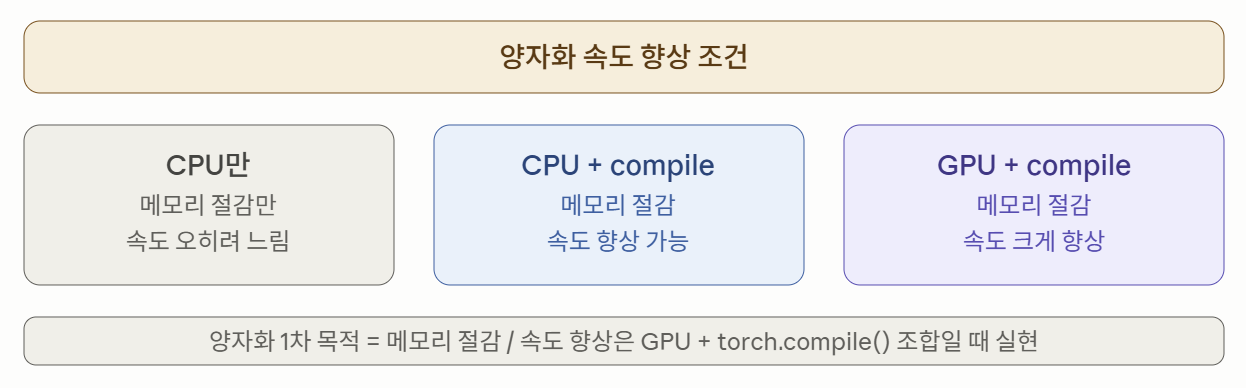

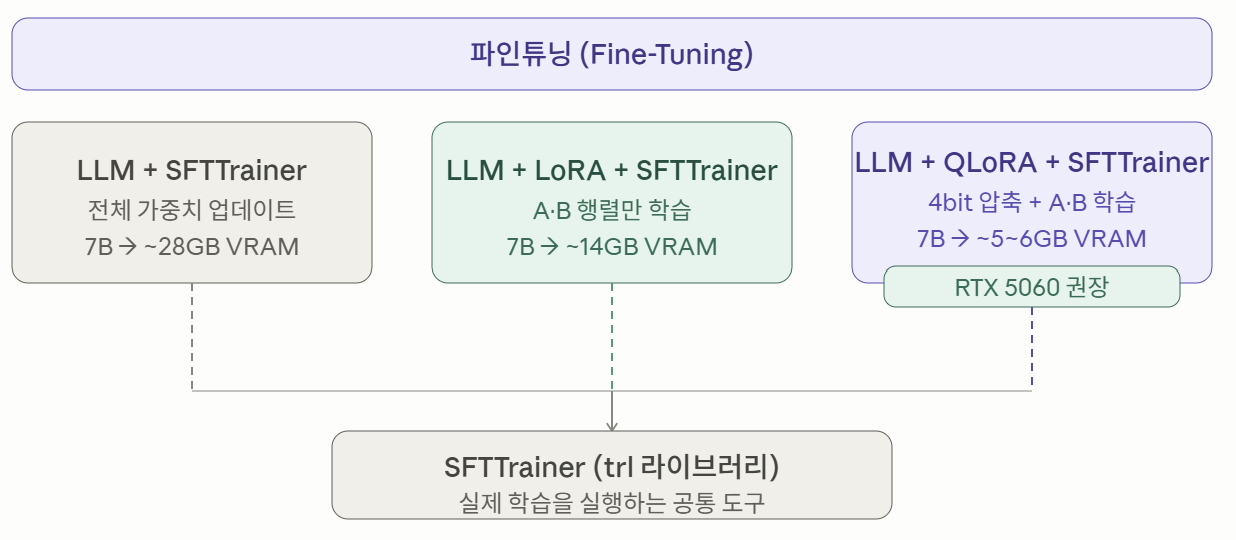

In [1]:
# 세 가지 조합 중 RTX 5060 환경에서는 LLM + QLoRA + SFTTrainer가 유일하게 현실적인 선택입니다.
# 7B 모델을 5~6GB VRAM으로 학습할 수 있기 때문입니다. 
# SFTTrainer는 세 조합 모두에서 실제 학습을 실행하는 공통 도구이고, 
# 데이터 형식(instruction/output, messages, prompt/completion)만 맞추면 동일한 코드로 동작합니다.

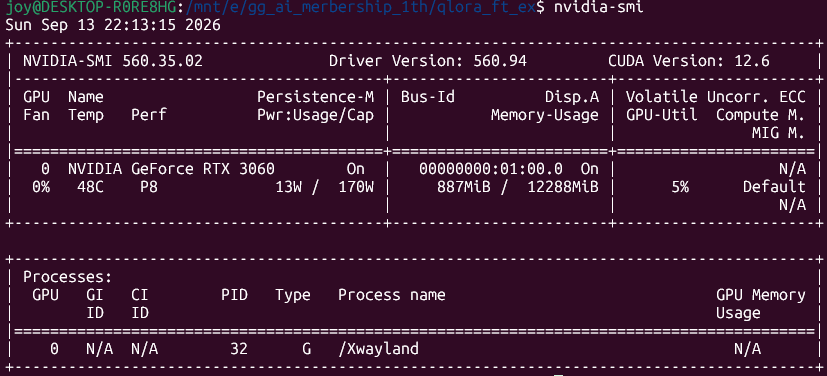

- 학습(QLoRA) → bitsandbytes가 사실상의 표준입니다.
- 서비스/배포 → GGUF(Ollama), GPTQ, AWQ, TensorRT-LLM 등이 더 많이 사용됩니다.
- 메모리가 부족한 개발 환경 → bitsandbytes는 큰 장점을 제공합니다.
- "양자화 = 속도 향상"이라고 이해하기보다는,
### 양자화의 핵심 목적은 메모리 절약이며, 속도 향상은 메모리 병목이 줄어들거나 양자화 전용 추론 엔진을 사용할 때 얻을 수 있는 추가적인 이점이라고 이해하는 것이 정확합니다